# Lab 2 — Visualization notebook

**This notebook is a working tool, not a deliverable — you do NOT submit it.**

It contains no logic of its own: it imports your finished functions from `../src/lab02.py`
and plots their output. If a cell below fails, the bug is in your `.py`, not in the plot.

Your job: complete the three plot cells, then **export each figure and paste it into
`report.pdf`** (right-click → Save image as…, or `plt.savefig('fig1.png', dpi=150)`).
Figures 1–3 are required by the report template.

In [1]:
import sys
sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
import lab02

X, y = lab02.load_data('../data/clinic_noshow.csv')
results = lab02.run_experiment(X, y)
results

{'baseline': {'accuracy': 0.65, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 'logreg': {'accuracy': 0.6917,
  'precision': 0.5735,
  'recall': 0.4643,
  'f1': 0.5132},
 'knn': {'accuracy': 0.6917,
  'precision': 0.5806,
  'recall': 0.4286,
  'f1': 0.4932}}

## Plot 1 — Class balance

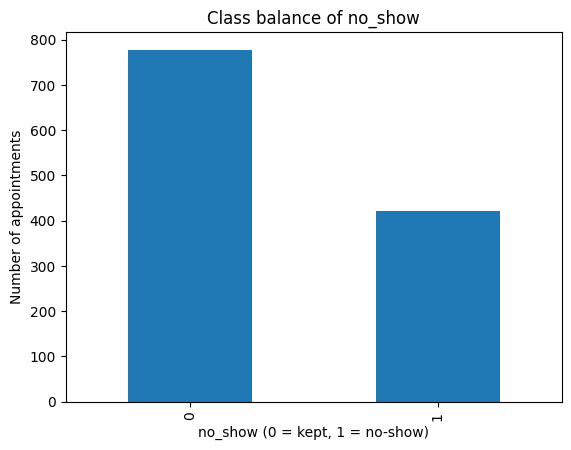

In [2]:
y.value_counts().plot(kind="bar")
plt.xlabel("no_show (0 = kept, 1 = no-show)")
plt.ylabel("Number of appointments")
plt.title("Class balance of no_show")
plt.savefig("fig1.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 2 — One feature, split by class

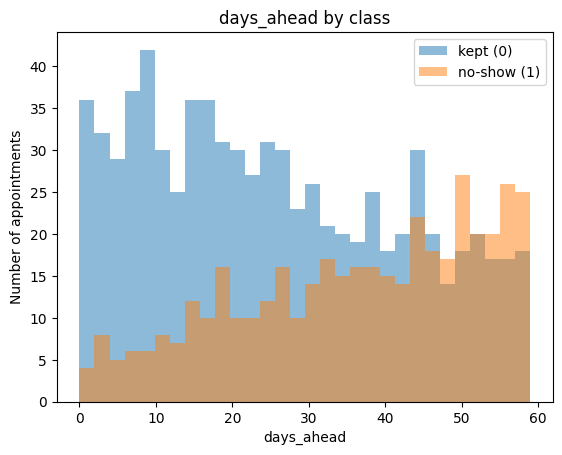

In [3]:
plt.hist(X.loc[y == 0, "days_ahead"], bins=30, alpha=0.5, label="kept (0)")
plt.hist(X.loc[y == 1, "days_ahead"], bins=30, alpha=0.5, label="no-show (1)")
plt.xlabel("days_ahead")
plt.ylabel("Number of appointments")
plt.title("days_ahead by class")
plt.legend()
plt.savefig("fig2.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 3 — Model comparison

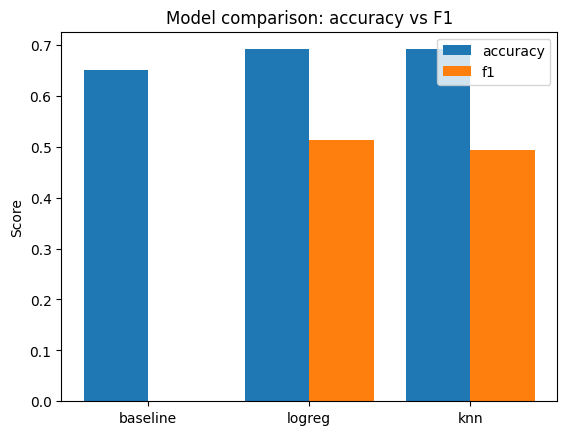

In [4]:
import numpy as np
names = ["baseline", "logreg", "knn"]
acc = [results[n]["accuracy"] for n in names]
f1  = [results[n]["f1"] for n in names]

x = np.arange(len(names))
plt.bar(x - 0.2, acc, width=0.4, label="accuracy")
plt.bar(x + 0.2, f1,  width=0.4, label="f1")
plt.xticks(x, names)
plt.ylabel("Score")
plt.title("Model comparison: accuracy vs F1")
plt.legend()
plt.savefig("fig3.png", dpi=150, bbox_inches="tight")
plt.show()